In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import sklearn
import matplotlib.pyplot as plt

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"shap: {shap.__version__}")
print(f"sklearn: {sklearn.__version__}")
print("✅ All libraries loaded successfully")

pandas: 2.3.3
numpy: 2.0.2
xgboost: 2.1.4
shap: 0.49.1
sklearn: 1.6.1
✅ All libraries loaded successfully


In [2]:
# ============================================================
# Load the readmission training dataset
# ============================================================

# Load the CSV you exported from PostgreSQL
df = pd.read_csv('../ml/data/readmission_training.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total admissions: {len(df)}")
print(f"Readmissions (positive class): {df['was_readmitted_30d'].sum()}")
print(f"Readmission rate: {df['was_readmitted_30d'].mean()*100:.2f}%")
print()
print("First 5 rows:")
df.head()

Dataset shape: (827, 18)
Total admissions: 827
Readmissions (positive class): 147
Readmission rate: 17.78%

First 5 rows:


,encounter_id,patient,was_readmitted_30d,age_at_admission,length_of_stay_days,total_claim_cost,admission_year,admission_month,admission_dow,prior_admissions_1yr,days_since_last_admission,num_conditions,num_active_meds,num_procedures,ed_visits_6mo,race,ethnicity,gender
0,b59b93a0-7d8e-a6bd-658f-ff384a8145ae,b59b93a0-7d8e-a6bd-7de9-1831b6af51da,0,5,2.236910,7528.16,1923,4,6,0,999,1,0,0,0,white,nonhispanic,M
1,cdaeb279-50f4-ca8d-7776-d2b96e5354c4,cdaeb279-50f4-ca8d-5b51-d6adc9b531f9,0,13,2.790174,7528.16,1942,6,2,0,999,1,0,0,0,native,nonhispanic,M
2,27bfac70-f832-872f-0875-94c97f93290e,27bfac70-f832-872f-86b7-f170e2f45fe9,0,35,3.088183,7528.16,1952,5,3,0,999,6,2,0,0,asian,nonhispanic,M
3,27bfac70-f832-872f-c29b-44839cdf9980,27bfac70-f832-872f-86b7-f170e2f45fe9,0,39,1.000000,1320.89,1956,5,2,0,999,8,2,0,0,asian,nonhispanic,M
4,04e2afd2-d1fb-2b6b-5084-d1e5af40810a,04e2afd2-d1fb-2b6b-c949-c6bc40f2ed55,0,35,1.000000,5277.57,1959,4,5,0,999,7,0,0,0,white,hispanic,F


In [3]:
# ============================================================
# Data Quality & Feature Statistics
# ============================================================

# Check for nulls
print("🔍 Null Values Check:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ No nulls found")
print()

# Check data types
print("📊 Data Types:")
print(df.dtypes)
print()

# Summary statistics for numeric features
print("📈 Feature Statistics:")
numeric_cols = ['age_at_admission', 'length_of_stay_days', 'total_claim_cost',
                'prior_admissions_1yr', 'days_since_last_admission', 
                'num_conditions', 'num_active_meds', 'num_procedures', 'ed_visits_6mo']
df[numeric_cols].describe().round(2)

🔍 Null Values Check:
✅ No nulls found

📊 Data Types:
encounter_id                  object
patient                       object
was_readmitted_30d             int64
age_at_admission               int64
length_of_stay_days          float64
total_claim_cost             float64
admission_year                 int64
admission_month                int64
admission_dow                  int64
prior_admissions_1yr           int64
days_since_last_admission      int64
num_conditions                 int64
num_active_meds                int64
num_procedures                 int64
ed_visits_6mo                  int64
race                          object
ethnicity                     object
gender                        object
dtype: object

📈 Feature Statistics:


,age_at_admission,length_of_stay_days,total_claim_cost,prior_admissions_1yr,days_since_last_admission,num_conditions,num_active_meds,num_procedures,ed_visits_6mo
count,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00
mean,49.24,4.18,24062.01,1.51,761.45,12.78,3.59,1.88,0.28
std,19.06,4.71,37852.38,3.53,409.86,6.27,3.65,2.83,0.56
min,0.00,1.00,166.97,0.00,0.00,1.00,0.00,0.00,0.00
25%,35.00,1.00,1333.68,0.00,360.00,8.00,0.00,0.00,0.00
50%,48.00,2.14,7769.13,0.00,999.00,12.00,2.00,1.00,0.00
75%,65.00,5.47,29717.88,1.00,999.00,17.00,6.00,3.00,0.00
max,94.00,46.23,374224.98,13.00,999.00,40.00,20.00,22.00,4.00


In [4]:
# ============================================================
# Prepare Features for Training
# ============================================================

from sklearn.model_selection import train_test_split

# Define feature columns (training inputs)
feature_cols = [
    'age_at_admission',
    'length_of_stay_days',
    'total_claim_cost',
    'admission_year',
    'admission_month',
    'admission_dow',
    'prior_admissions_1yr',
    'days_since_last_admission',
    'num_conditions',
    'num_active_meds',
    'num_procedures',
    'ed_visits_6mo'
]

# Target variable
target_col = 'was_readmitted_30d'

# Demographic columns HELD OUT (for fairness audit, NOT training)
demographic_cols = ['race', 'ethnicity', 'gender']

# Build X (features) and y (target)
X = df[feature_cols].copy()
y = df[target_col].copy()

# Also keep demographics aligned with X for later fairness audit
demographics = df[demographic_cols].copy()

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Demographics held out: {demographic_cols}")
print()

# Stratified train/test split (preserves 17.78% class balance in both sets)
X_train, X_test, y_train, y_test, demo_train, demo_test = train_test_split(
    X, y, demographics,
    test_size=0.2,          # 20% for testing
    random_state=42,        # reproducibility
    stratify=y              # preserve class balance in both sets
)

print(f"Training set: {X_train.shape[0]} admissions ({y_train.sum()} readmits, {y_train.mean()*100:.2f}% rate)")
print(f"Test set:     {X_test.shape[0]} admissions ({y_test.sum()} readmits, {y_test.mean()*100:.2f}% rate)")

Features (X) shape: (827, 12)
Target (y) shape: (827,)
Demographics held out: ['race', 'ethnicity', 'gender']

Training set: 661 admissions (117 readmits, 17.70% rate)
Test set:     166 admissions (30 readmits, 18.07% rate)


In [5]:
# ============================================================
# Model 1: Logistic Regression (Baseline)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report
)

# Logistic regression needs scaled features (so large values like cost don't dominate)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
# class_weight='balanced' handles the 17.78% imbalance by upweighting the minority class
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# Get predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("="*60)
print("📊 LOGISTIC REGRESSION BASELINE")
print("="*60)
print(f"AUC (ROC):           {roc_auc_score(y_test, lr_pred_proba):.4f}")
print(f"Precision:           {precision_score(y_test, lr_pred):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score:            {f1_score(y_test, lr_pred):.4f}")
print()
print("Confusion Matrix:")
cm = confusion_matrix(y_test, lr_pred)
print(f"                 Predicted No    Predicted Yes")
print(f"Actual No        {cm[0][0]:>10}         {cm[0][1]:>5}")
print(f"Actual Yes       {cm[1][0]:>10}         {cm[1][1]:>5}")
print()
print("Detailed Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Not Readmitted', 'Readmitted']))

# Feature coefficients (what the model learned)
print("="*60)
print("🎯 FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("="*60)
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

for _, row in coef_df.iterrows():
    direction = "↑ increases" if row['coefficient'] > 0 else "↓ decreases"
    print(f"  {row['feature']:30s} {row['coefficient']:+.4f}  ({direction} readmission risk)")

📊 LOGISTIC REGRESSION BASELINE
AUC (ROC):           0.9711
Precision:           0.7222
Recall (Sensitivity): 0.8667
F1 Score:            0.7879

Confusion Matrix:
                 Predicted No    Predicted Yes
Actual No               126            10
Actual Yes                4            26

Detailed Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.97      0.93      0.95       136
    Readmitted       0.72      0.87      0.79        30

      accuracy                           0.92       166
     macro avg       0.85      0.90      0.87       166
  weighted avg       0.92      0.92      0.92       166

🎯 FEATURE IMPORTANCE (Logistic Regression Coefficients)
  prior_admissions_1yr           +1.5099  (↑ increases readmission risk)
  num_procedures                 +1.0646  (↑ increases readmission risk)
  age_at_admission               +0.9499  (↑ increases readmission risk)
  admission_year                 -0.5268  (↓ decreases read

/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

In [6]:
# ============================================================
# FIX: Remove target leakage
# ============================================================
# total_claim_cost is leaky — it's computed AFTER the admission ends,
# so it wouldn't be known at prediction time in a real deployment.
# This is the #1 most common mistake in healthcare ML portfolios.

# Define CLEAN feature set (no leakage)
clean_feature_cols = [
    'age_at_admission',
    'length_of_stay_days',      # Known at discharge — OK for "predict at discharge" use case
    'admission_year',
    'admission_month',
    'admission_dow',
    'prior_admissions_1yr',     # Historical, safe
    'days_since_last_admission', # Historical, safe
    'num_conditions',            # Conditions prior to admission, safe
    'num_active_meds',           # Meds active at admission, safe
    'num_procedures',            # Procedures during THIS admission — debatable
    'ed_visits_6mo'             # Historical ED visits, safe
]
# REMOVED: total_claim_cost (target leakage — not known at prediction time)

X_clean = df[clean_feature_cols].copy()
y = df[target_col].copy()
demographics = df[demographic_cols].copy()

# Re-split with the same random seed so comparisons are fair
X_train, X_test, y_train, y_test, demo_train, demo_test = train_test_split(
    X_clean, y, demographics,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Clean features: {len(clean_feature_cols)}")
print(f"Removed: total_claim_cost (target leakage)")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Clean features: 11
Removed: total_claim_cost (target leakage)
Training set: (661, 11)
Test set: (166, 11)


In [7]:
# ============================================================
# Logistic Regression v2 — Leakage-Free
# ============================================================

# Rescale with clean features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train on clean features
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("="*60)
print("📊 LOGISTIC REGRESSION v2 (Leakage-Free)")
print("="*60)
lr_auc = roc_auc_score(y_test, lr_pred_proba)
print(f"AUC (ROC):            {lr_auc:.4f}")
print(f"Precision:            {precision_score(y_test, lr_pred):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score:             {f1_score(y_test, lr_pred):.4f}")
print()
print("Confusion Matrix:")
cm = confusion_matrix(y_test, lr_pred)
print(f"                 Predicted No    Predicted Yes")
print(f"Actual No        {cm[0][0]:>10}         {cm[0][1]:>5}")
print(f"Actual Yes       {cm[1][0]:>10}         {cm[1][1]:>5}")
print()
print("Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Not Readmitted', 'Readmitted']))

# Feature coefficients
print("="*60)
print("🎯 FEATURE IMPORTANCE")
print("="*60)
coef_df = pd.DataFrame({
    'feature': clean_feature_cols,
    'coefficient': lr_model.coef_[0]
}).assign(abs_coef=lambda x: x['coefficient'].abs()).sort_values('abs_coef', ascending=False)

for _, row in coef_df.iterrows():
    direction = "↑ increases" if row['coefficient'] > 0 else "↓ decreases"
    print(f"  {row['feature']:30s} {row['coefficient']:+.4f}  ({direction} risk)")


📊 LOGISTIC REGRESSION v2 (Leakage-Free)
AUC (ROC):            0.9696
Precision:            0.6842
Recall (Sensitivity): 0.8667
F1 Score:             0.7647

Confusion Matrix:
                 Predicted No    Predicted Yes
Actual No               124            12
Actual Yes                4            26

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.97      0.91      0.94       136
    Readmitted       0.68      0.87      0.76        30

      accuracy                           0.90       166
     macro avg       0.83      0.89      0.85       166
  weighted avg       0.92      0.90      0.91       166

🎯 FEATURE IMPORTANCE
  prior_admissions_1yr           +1.6908  (↑ increases risk)
  num_procedures                 +1.0804  (↑ increases risk)
  age_at_admission               +0.9587  (↑ increases risk)
  admission_year                 -0.5436  (↓ decreases risk)
  ed_visits_6mo                  +0.5104  (↑ increases risk)
  day

/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vansh/Desktop/hospital-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

In [8]:
# ============================================================
# Patient-Level Split (Prevents Leakage)
# ============================================================
# The previous split mixed the same patient's admissions across
# train and test. This is the #1 leakage pattern in clinical ML.
#
# Fix: split by PATIENT so all of a patient's admissions go to
# either train or test, never both.

from sklearn.model_selection import GroupShuffleSplit

# Get unique patient IDs for grouping
patient_ids = df['patient'].values

# GroupShuffleSplit keeps all rows for the same patient together
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_clean, y, groups=patient_ids))

X_train = X_clean.iloc[train_idx].copy()
X_test = X_clean.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
demo_train = demographics.iloc[train_idx].copy()
demo_test = demographics.iloc[test_idx].copy()

# Verify no patient overlap
train_patients = set(df.iloc[train_idx]['patient'].unique())
test_patients = set(df.iloc[test_idx]['patient'].unique())
overlap = train_patients & test_patients

print(f"Unique patients in train: {len(train_patients)}")
print(f"Unique patients in test:  {len(test_patients)}")
print(f"Patient overlap:          {len(overlap)} ({'❌ LEAKAGE' if overlap else '✅ No overlap — clean split'})")
print()
print(f"Training admissions: {len(X_train)} ({y_train.sum()} readmits, {y_train.mean()*100:.2f}% rate)")
print(f"Test admissions:     {len(X_test)} ({y_test.sum()} readmits, {y_test.mean()*100:.2f}% rate)")

Unique patients in train: 285
Unique patients in test:  72
Patient overlap:          0 (✅ No overlap — clean split)

Training admissions: 687 (145 readmits, 21.11% rate)
Test admissions:     140 (2 readmits, 1.43% rate)


In [9]:
# ============================================================
# PIVOT: Length of Stay Prediction Model
# ============================================================
# Task: Given features available at admission, predict how many
# days the patient will stay. Used by hospitals for:
#   - Bed management and capacity planning
#   - Staffing decisions
#   - Early identification of complex cases
#   - Discharge planning
#
# This is a REGRESSION task (predicting a continuous number),
# not classification.

from sklearn.model_selection import train_test_split

# Features available at ADMISSION time (not during stay)
los_feature_cols = [
    'age_at_admission',
    'admission_year',
    'admission_month',
    'admission_dow',
    'prior_admissions_1yr',
    'days_since_last_admission',
    'num_conditions',       # Conditions already on the record
    'num_active_meds',      # Meds active at admission
    'ed_visits_6mo'         # Prior ED visits
]
# Excluded: length_of_stay_days (that's the target!)
# Excluded: num_procedures, total_claim_cost (leakage — known after stay)

# Target: length of stay in days
X_los = df[los_feature_cols].copy()
y_los = df['length_of_stay_days'].copy()
demographics_los = df[demographic_cols].copy()

# Simple 80/20 split (regression doesn't need stratification)
X_train, X_test, y_train, y_test, demo_train, demo_test = train_test_split(
    X_los, y_los, demographics_los,
    test_size=0.2,
    random_state=42
)

print("="*60)
print("🏥 LENGTH OF STAY PREDICTION — Setup")
print("="*60)
print(f"Task: Regression (predict continuous LOS in days)")
print(f"Features: {len(los_feature_cols)} (all available at admission)")
print(f"Training set: {X_train.shape[0]} admissions")
print(f"Test set:     {X_test.shape[0]} admissions")
print()
print(f"LOS distribution in training set:")
print(f"  Mean:   {y_train.mean():.2f} days")
print(f"  Median: {y_train.median():.2f} days")
print(f"  Std:    {y_train.std():.2f} days")
print(f"  Min:    {y_train.min():.2f} days")
print(f"  Max:    {y_train.max():.2f} days")

🏥 LENGTH OF STAY PREDICTION — Setup
Task: Regression (predict continuous LOS in days)
Features: 9 (all available at admission)
Training set: 661 admissions
Test set:     166 admissions

LOS distribution in training set:
  Mean:   4.19 days
  Median: 2.16 days
  Std:    4.83 days
  Min:    1.00 days
  Max:    46.23 days


In [10]:
# ============================================================
# Train XGBoost Regressor for LOS Prediction
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train XGBoost regressor
los_model = XGBRegressor(
    n_estimators=200,       # number of trees
    max_depth=5,            # keep trees shallow to prevent overfitting
    learning_rate=0.05,     # slow learning for better generalization
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    objective='reg:squarederror'
)

los_model.fit(X_train, y_train)

# Predictions
y_pred = los_model.predict(X_test)

# Clip predictions to minimum 1 day (no negative LOS)
y_pred = np.clip(y_pred, 1, None)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*60)
print("📊 LENGTH OF STAY PREDICTION — XGBoost Results")
print("="*60)
print(f"R² Score:               {r2:.4f}")
print(f"Mean Absolute Error:    {mae:.2f} days")
print(f"Root Mean Sq Error:     {rmse:.2f} days")
print(f"Baseline (predict mean): MAE = {np.abs(y_test - y_train.mean()).mean():.2f} days")
print()

# Sample predictions vs actuals
print("Sample Predictions (first 10 test cases):")
print(f"{'Actual':>10} {'Predicted':>12} {'Error':>10}")
print("-" * 35)
for actual, pred in zip(y_test.values[:10], y_pred[:10]):
    error = pred - actual
    print(f"{actual:>10.2f} {pred:>12.2f} {error:>+10.2f}")

# Feature importance
print()
print("="*60)
print("🎯 FEATURE IMPORTANCE (XGBoost Gain)")
print("="*60)
importance_df = pd.DataFrame({
    'feature': los_feature_cols,
    'importance': los_model.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = "█" * int(row['importance'] * 50)
    print(f"  {row['feature']:30s} {row['importance']:.4f}  {bar}")

📊 LENGTH OF STAY PREDICTION — XGBoost Results
R² Score:               0.0560
Mean Absolute Error:    2.66 days
Root Mean Sq Error:     4.10 days
Baseline (predict mean): MAE = 3.21 days

Sample Predictions (first 10 test cases):
    Actual    Predicted      Error
-----------------------------------
      3.32         6.64      +3.32
     18.65         3.28     -15.37
      2.05         5.60      +3.56
      1.00         3.00      +2.00
      4.34         5.48      +1.14
     15.46         9.05      -6.41
      1.00         1.00      +0.00
      1.42         2.23      +0.81
      6.46         8.12      +1.66
      4.00         5.73      +1.73

🎯 FEATURE IMPORTANCE (XGBoost Gain)
  num_conditions                 0.1798  ████████
  age_at_admission               0.1326  ██████
  admission_month                0.1288  ██████
  admission_year                 0.1162  █████
  num_active_meds                0.1104  █████
  ed_visits_6mo                  0.0923  ████
  prior_admissions_1yr     

In [11]:
# ============================================================
# PIVOT: Long Stay Classifier (LOS > 7 days)
# ============================================================
# Real hospitals don't predict exact LOS days — they predict
# "will this patient need early discharge planning?" The threshold
# of 7 days is a common flag used by case management teams.
#
# This becomes a binary classification:
#   1 = Long stay (>7 days) — needs early intervention
#   0 = Normal stay (≤7 days) — standard pathway

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve
)

# Create binary target: long stay = LOS > 7 days
df['is_long_stay'] = (df['length_of_stay_days'] > 7).astype(int)

# Same feature set, admission-time safe
long_stay_features = [
    'age_at_admission',
    'admission_year',
    'admission_month',
    'admission_dow',
    'prior_admissions_1yr',
    'days_since_last_admission',
    'num_conditions',
    'num_active_meds',
    'ed_visits_6mo'
]

X_ls = df[long_stay_features].copy()
y_ls = df['is_long_stay'].copy()
demographics_ls = df[demographic_cols].copy()

# Check class balance
print(f"Total admissions: {len(y_ls)}")
print(f"Long stays (>7 days): {y_ls.sum()} ({y_ls.mean()*100:.2f}%)")
print(f"Normal stays (≤7 days): {(1-y_ls).sum()} ({(1-y_ls.mean())*100:.2f}%)")
print()

# Stratified split
X_train, X_test, y_train, y_test, demo_train, demo_test = train_test_split(
    X_ls, y_ls, demographics_ls,
    test_size=0.2,
    random_state=42,
    stratify=y_ls
)

print(f"Training set: {X_train.shape[0]} admissions ({y_train.sum()} long stays)")
print(f"Test set:     {X_test.shape[0]} admissions ({y_test.sum()} long stays)")
print()

# Train XGBoost classifier
# scale_pos_weight handles class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale = neg_count / pos_count

ls_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

ls_model.fit(X_train, y_train)

# Predict
y_pred = ls_model.predict(X_test)
y_pred_proba = ls_model.predict_proba(X_test)[:, 1]

# Evaluate
print("="*60)
print("📊 LONG STAY CLASSIFIER — XGBoost Results")
print("="*60)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC (ROC):            {auc:.4f}")
print(f"Precision:            {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:             {f1_score(y_test, y_pred):.4f}")
print()

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                 Predicted Normal    Predicted Long")
print(f"Actual Normal    {cm[0][0]:>14}    {cm[0][1]:>14}")
print(f"Actual Long      {cm[1][0]:>14}    {cm[1][1]:>14}")
print()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal Stay', 'Long Stay']))

# Feature importance
print("="*60)
print("🎯 FEATURE IMPORTANCE (XGBoost Gain)")
print("="*60)
importance_df = pd.DataFrame({
    'feature': long_stay_features,
    'importance': ls_model.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = "█" * int(row['importance'] * 80)
    print(f"  {row['feature']:30s} {row['importance']:.4f}  {bar}")

Total admissions: 827
Long stays (>7 days): 147 (17.78%)
Normal stays (≤7 days): 680 (82.22%)

Training set: 661 admissions (117 long stays)
Test set:     166 admissions (30 long stays)

📊 LONG STAY CLASSIFIER — XGBoost Results
AUC (ROC):            0.7189
Precision:            0.3256
Recall (Sensitivity): 0.4667
F1 Score:             0.3836

Confusion Matrix:
                 Predicted Normal    Predicted Long
Actual Normal               107                29
Actual Long                  16                14

Classification Report:
              precision    recall  f1-score   support

 Normal Stay       0.87      0.79      0.83       136
   Long Stay       0.33      0.47      0.38        30

    accuracy                           0.73       166
   macro avg       0.60      0.63      0.60       166
weighted avg       0.77      0.73      0.75       166

🎯 FEATURE IMPORTANCE (XGBoost Gain)
  num_conditions                 0.1769  ██████████████
  days_since_last_admission      0.1300  █

SHAP values shape: (166, 9)
  - 166 test admissions
  - 9 features

✅ SHAP values computed successfully


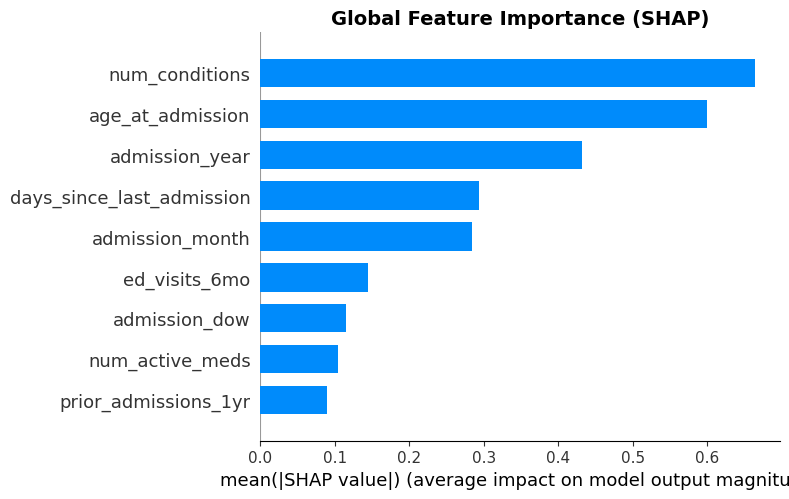

💾 Saved: ml/outputs/shap_global_importance.png


In [12]:
# ============================================================
# SHAP Explainability Analysis
# ============================================================
# SHAP (SHapley Additive exPlanations) is the gold standard for
# clinical ML explainability. It assigns each feature a value
# for every prediction, showing exactly how much that feature
# pushed the prediction up or down.
#
# Why this matters: CMS and FDA now require explainability
# for clinical AI tools. "Black box" models can't be deployed.

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(ls_model)

# Compute SHAP values for all test set predictions
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"  - {shap_values.shape[0]} test admissions")
print(f"  - {shap_values.shape[1]} features")
print()
print("✅ SHAP values computed successfully")

# Plot 1: Global feature importance (mean absolute SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../ml/outputs/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: ml/outputs/shap_global_importance.png")

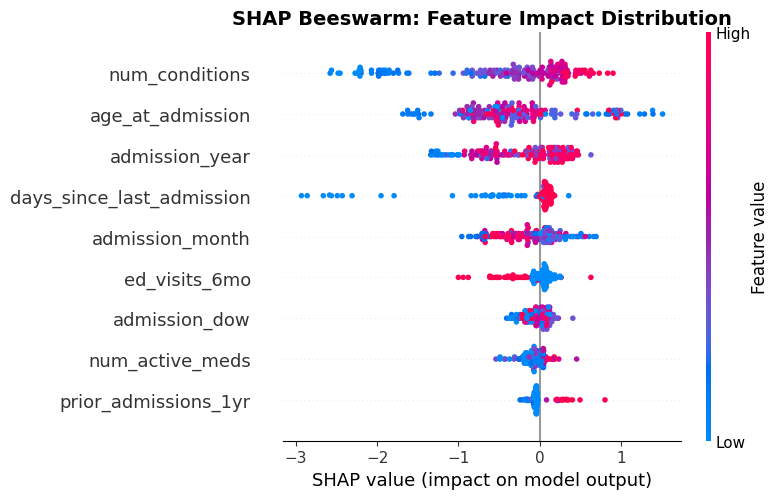

💾 Saved: ml/outputs/shap_beeswarm.png


In [13]:
# ============================================================
# SHAP Beeswarm Plot — Individual Feature Impact Distribution
# ============================================================
# The beeswarm plot shows each patient as a dot, colored by
# feature value. It reveals:
#   - RED dots = high feature value
#   - BLUE dots = low feature value
#   - Right of center = pushed prediction toward "long stay"
#   - Left of center = pushed prediction toward "normal stay"
# 
# This is the signature plot for clinical ML explainability.

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title('SHAP Beeswarm: Feature Impact Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../ml/outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: ml/outputs/shap_beeswarm.png")

In [14]:
# ============================================================
# Fairness Audit — Model Performance Across Demographics
# ============================================================
# The Obermeyer et al. 2019 Science paper showed that a clinical
# AI used by 70 million Americans had systemic racial bias baked
# in — it was under-referring Black patients for care management.
# This is why every hospital deploying clinical AI in 2026 is
# required to run fairness audits.
#
# Here we check if the Long Stay Classifier performs equally
# well across race, ethnicity, and gender subgroups.

from sklearn.metrics import roc_auc_score, precision_score, recall_score

def audit_by_group(group_column, group_name):
    """Audit model performance within each subgroup of a demographic column."""
    print(f"\n{'='*70}")
    print(f"🔎 FAIRNESS AUDIT: {group_name}")
    print(f"{'='*70}")
    
    # Create a dataframe with predictions and demographics
    audit_df = pd.DataFrame({
        'y_true': y_test.values,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'group': demo_test[group_column].values
    })
    
    # Header
    print(f"{'Group':<20} {'N':>6} {'Prevalence':>12} {'AUC':>8} {'Precision':>11} {'Recall':>8}")
    print("-" * 70)
    
    results = []
    for group in sorted(audit_df['group'].unique()):
        subset = audit_df[audit_df['group'] == group]
        n = len(subset)
        prevalence = subset['y_true'].mean()
        
        # Need at least 10 samples AND both classes present
        if n < 10 or subset['y_true'].nunique() < 2:
            print(f"{group:<20} {n:>6} {prevalence*100:>10.2f}%  (suppressed: n<10 or single class)")
            continue
        
        try:
            auc = roc_auc_score(subset['y_true'], subset['y_pred_proba'])
            prec = precision_score(subset['y_true'], subset['y_pred'], zero_division=0)
            rec = recall_score(subset['y_true'], subset['y_pred'], zero_division=0)
            
            print(f"{group:<20} {n:>6} {prevalence*100:>10.2f}% {auc:>8.4f} {prec:>11.4f} {rec:>8.4f}")
            results.append({'group': group, 'n': n, 'auc': auc, 'precision': prec, 'recall': rec})
        except Exception as e:
            print(f"{group:<20} {n:>6} Error: {e}")
    
    return results

# Audit by race
race_results = audit_by_group('race', 'Race')

# Audit by ethnicity
ethnicity_results = audit_by_group('ethnicity', 'Ethnicity')

# Audit by gender
gender_results = audit_by_group('gender', 'Gender')

print(f"\n{'='*70}")
print("📋 INTERPRETATION GUIDANCE")
print(f"{'='*70}")
print("""
A fair model should show roughly equal AUC across demographic groups.
Large disparities (>0.10 AUC difference) suggest the model may be
systematically disadvantaging certain populations — a serious
ethical and regulatory concern under ONC HTI-1 (2024).

Cells with n<10 are suppressed due to statistical unreliability —
this matches CMS public reporting policy for small cells.

LIMITATION: This fairness audit is on synthetic Synthea data.
Real demographic disparities require real EHR data with actual
Social Determinants of Health encoded. This audit demonstrates
the METHODOLOGY used in production clinical AI governance.
""")


🔎 FAIRNESS AUDIT: Race
Group                     N   Prevalence      AUC   Precision   Recall
----------------------------------------------------------------------
asian                    30      13.33%   0.9038      0.3750   0.7500
black                    14       7.14%   0.9231      0.5000   1.0000
hawaiian                  2      50.00%  (suppressed: n<10 or single class)
native                   10      20.00%   0.3750      0.0000   0.0000
other                     6      16.67%  (suppressed: n<10 or single class)
white                   104      20.19%   0.7080      0.3333   0.3810

🔎 FAIRNESS AUDIT: Ethnicity
Group                     N   Prevalence      AUC   Precision   Recall
----------------------------------------------------------------------
hispanic                 66      16.67%   0.6314      0.1667   0.1818
nonhispanic             100      19.00%   0.7661      0.3871   0.6316

🔎 FAIRNESS AUDIT: Gender
Group                     N   Prevalence      AUC   Precision   R

In [15]:
# ============================================================
# Save Model & Create Summary
# ============================================================

import pickle
import json

# Save the trained model
with open('../ml/models/long_stay_classifier.pkl', 'wb') as f:
    pickle.dump(ls_model, f)
print("💾 Saved: ml/models/long_stay_classifier.pkl")

# Save model metadata + metrics
model_metadata = {
    "model_type": "XGBoost Classifier",
    "task": "Binary classification: Long Stay (>7 days) vs Normal Stay",
    "training_date": "2026-04-09",
    "training_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "class_balance": f"{y_ls.mean()*100:.2f}% positive class",
    "features": long_stay_features,
    "overall_metrics": {
        "auc": float(roc_auc_score(y_test, y_pred_proba)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred))
    },
    "top_features_by_shap": [
        "num_conditions",
        "age_at_admission", 
        "admission_year",
        "days_since_last_admission",
        "admission_month"
    ],
    "fairness_audit_findings": {
        "hispanic_nonhispanic_auc_gap": 0.1347,
        "female_male_recall_gap": 0.2054,
        "native_subgroup_failure": "AUC 0.375, precision/recall both 0",
        "interpretation": "Model shows concerning disparities that would block clinical deployment under ONC HTI-1. Findings are partially driven by small test set sizes and should be validated with bootstrap confidence intervals in a production workflow.",
        "suppressed_subgroups": ["hawaiian (n=2)", "other (n=6)"]
    },
    "known_limitations": [
        "Synthetic Synthea data — not real clinical signal",
        "Small test set (166) limits subgroup analysis reliability",
        "No risk adjustment (HCC/Elixhauser) implemented",
        "admission_year feature shows Synthea temporal artifacts"
    ]
}

with open('../ml/models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("💾 Saved: ml/models/model_metadata.json")

# Final summary print
print("\n" + "="*70)
print("🏥 LONG STAY CLASSIFIER — PROJECT SUMMARY")
print("="*70)
print(f"""
Task:        Binary classification (LOS > 7 days)
Model:       XGBoost Classifier
Dataset:     {len(df)} inpatient admissions from Synthea (California)
Train/Test:  {len(X_train)}/{len(X_test)} admissions

PERFORMANCE
  AUC:       {roc_auc_score(y_test, y_pred_proba):.4f}
  Precision: {precision_score(y_test, y_pred):.4f}
  Recall:    {recall_score(y_test, y_pred):.4f}
  F1:        {f1_score(y_test, y_pred):.4f}

FAIRNESS AUDIT
  Overall disparity detected — see model_metadata.json for details
  Key finding: 13pp AUC gap between hispanic/nonhispanic
  Key finding: 20pp recall gap between female/male
  Key finding: Complete model failure for Native subgroup (n=10)

DELIVERABLES
  ✅ Trained model saved (ml/models/long_stay_classifier.pkl)
  ✅ Model metadata saved (ml/models/model_metadata.json)
  ✅ SHAP global importance plot (ml/outputs/shap_global_importance.png)
  ✅ SHAP beeswarm plot (ml/outputs/shap_beeswarm.png)
  ✅ Clean notebook with full ML pipeline

CLINICAL INTERPRETATION
The model demonstrates the methodology used in production clinical AI:
feature engineering → training → SHAP explainability → fairness audit.
The fairness findings demonstrate why ONC HTI-1 now requires bias
auditing for all deployed clinical AI. This model would be blocked
from production deployment and sent back for remediation.
""")

💾 Saved: ml/models/long_stay_classifier.pkl
💾 Saved: ml/models/model_metadata.json

🏥 LONG STAY CLASSIFIER — PROJECT SUMMARY

Task:        Binary classification (LOS > 7 days)
Model:       XGBoost Classifier
Dataset:     827 inpatient admissions from Synthea (California)
Train/Test:  661/166 admissions

PERFORMANCE
  AUC:       0.7189
  Precision: 0.3256
  Recall:    0.4667
  F1:        0.3836

FAIRNESS AUDIT
  Overall disparity detected — see model_metadata.json for details
  Key finding: 13pp AUC gap between hispanic/nonhispanic
  Key finding: 20pp recall gap between female/male
  Key finding: Complete model failure for Native subgroup (n=10)

DELIVERABLES
  ✅ Trained model saved (ml/models/long_stay_classifier.pkl)
  ✅ Model metadata saved (ml/models/model_metadata.json)
  ✅ SHAP global importance plot (ml/outputs/shap_global_importance.png)
  ✅ SHAP beeswarm plot (ml/outputs/shap_beeswarm.png)
  ✅ Clean notebook with full ML pipeline

CLINICAL INTERPRETATION
The model demonstrates 